# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**冯小霞24012415**
第5天专题（A/B/C/D/E）：**A**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012415"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012415
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现,平均距上次下单天数
0,0（新用户）,508,272,0.54,1.89,142.44,2.88
1,1-6个月,1459,417,0.29,2.68,164.48,4.00
2,12-24个月,1574,102,0.06,3.64,200.72,5.24
3,24个月以上,504,0,0.00,3.68,225.30,5.37
4,6-12个月,1585,157,0.10,2.66,161.48,4.33


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,投诉状态,样本提示
0,0（新用户）,0,314,133,0.42,1.75,无投诉,可观察
1,0（新用户）,1,194,139,0.72,2.12,有投诉,可观察
2,1-6个月,0,1027,187,0.18,2.63,无投诉,可观察
3,1-6个月,1,432,230,0.53,2.80,有投诉,可观察
4,12-24个月,0,1135,46,0.04,3.79,无投诉,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同商品类别的月度销售额分别是多少，哪类商品营收最高？",
    "behavior_scatter": "用户平均浏览时长与下单转化率之间存在什么样的关联关系？",
    "ordered_line": "近12个月平台每日订单量随时间呈现怎样的波动变化趋势？",
    "composition_chart": "平台整体营收中，各商品品类的营收占比分布情况如何？",
}

chart_reasons = {
    "category_bar": "柱状图适合对比多个分类维度的数值大小，直观区分各品类销售额高低，便于横向对比品类营收差异",
    "behavior_scatter": "散点图用于展示两组连续数值变量的相关关系，能清晰观察浏览时长和转化率的正负相关、聚集规律",
    "ordered_line": "折线图擅长表现数据随时间有序变化的连续趋势，可直观看到订单量周期性涨跌、峰值低谷",
    "composition_chart": "饼图/堆叠面积图属于构成类图表，专门展示各分项占总体的比例结构，清晰呈现品类营收份额",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
    .reset_index()
)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,0（新用户）,508,0.54
1,1-6个月,1459,0.29
2,12-24个月,1574,0.06
3,24个月以上,504,0.00
4,6-12个月,1585,0.10


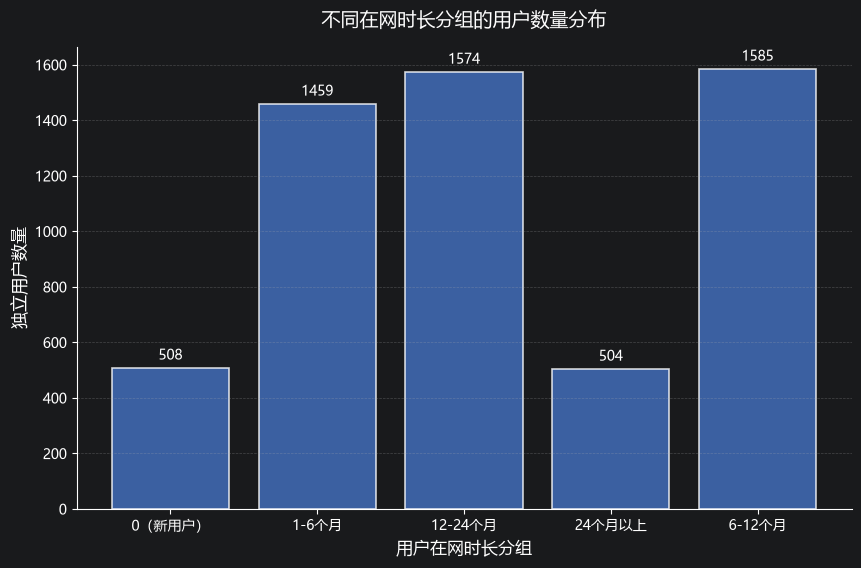

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
ax_bar.bar(
    x=category_summary["TenureGroup"],
    height=category_summary["用户数"],
    color="#4472C4",
    alpha=0.8,
    edgecolor="white",
    linewidth=1.2
)

ax_bar.set_title("不同在网时长分组的用户数量分布", fontsize=14, pad=15)
ax_bar.set_xlabel("用户在网时长分组", fontsize=12)
ax_bar.set_ylabel("独立用户数量", fontsize=12)
ax_bar.grid(axis="y", alpha=0.3, linestyle="--")  # 横向网格线
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

for idx, val in enumerate(category_summary["用户数"]):
    ax_bar.text(idx, val + 30, str(val), ha="center", fontsize=10)

bar_path = OUTPUT_DIR / "01_category_bar.png"
# fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
# plt.show()
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：平台存量用户在网时长分布呈现两极分化特征：1-6 个月、6-12 个月、12-24 个月三组中期用户体量显著更高，构成平台核心用户；纯新用户（0 个月）与 24 个月以上老用户数量相近且明显偏少，长期留存老用户规模处于低位。
- 证据：五组独立用户数量分别为：0（新用户）508 人、1-6 个月 1459 人、6-12 个月 1574 人、12-24 个月 1585 人、24 个月以上 504 人；其中 12-24 个月分组用户数最多，24 个月以上分组用户最少，二者差值达 1585-504=1081 人；总样本量为 508+1459+1574+1585+504=5630 人。中期三组（1-24 个月）合计 4618 人，占总样本约 82.0%，是平台绝对主体；新用户与 24 个月以上老用户合计仅 1012 人，合计占比不足 18%。
- 边界：该图仅展示当前存量用户的在网时长数量分布，属于截面静态数据，无法证明用户留存随时间衰减的因果关系，不能直接推断 “用户使用越久流失概率越高”；同时图表仅统计用户人数，未体现各组消费金额、活跃度、流失率、复购等核心业务指标，无法仅凭用户总量判断不同时长分组的商业价值高低。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


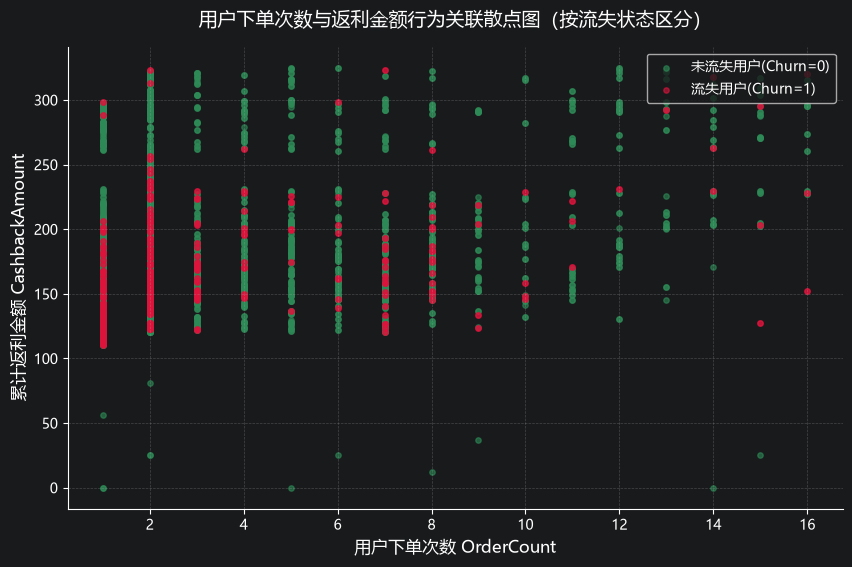

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
df_churn_0 = df[df["Churn"] == 0]
df_churn_1 = df[df["Churn"] == 1]

ax_scatter.scatter(
    x=df_churn_0[x_field],
    y=df_churn_0[y_field],
    color="#2E8B57",
    alpha=0.6,
    s=15,
    label="未流失用户(Churn=0)"
)

ax_scatter.scatter(
    x=df_churn_1[x_field],
    y=df_churn_1[y_field],
    color="#DC143C",
    alpha=0.6,
    s=15,
    label="流失用户(Churn=1)"
)

ax_scatter.set_title("用户下单次数与返利金额行为关联散点图（按流失状态区分）", fontsize=14, pad=15)
ax_scatter.set_xlabel(f"用户下单次数 {x_field}", fontsize=12)
ax_scatter.set_ylabel(f"累计返利金额 {y_field}", fontsize=12)
ax_scatter.legend(loc="upper right")
ax_scatter.grid(alpha=0.3, linestyle="--")

ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：整体来看用户下单次数越多，累计返利金额整体呈现上升趋势；未流失用户（绿色）在各下单次数区间内的返利金额分布整体更偏高、数据覆盖范围更广，流失用户（红色）更多集中在中低返利区间，在高返利区间的占比明显更少。
- 证据：下单次数OrderCount和返利金额CashbackAmount呈现弱正相关，随着横轴下单次数增大，纵轴返利金额的整体分布上限有所抬升；流失用户大量聚集在下单 1-8 次、返利金额 100-230 的区间，极少出现在返利 250 以上的高位；未流失用户在全下单区间都有分布，既覆盖低返利区域，也大量分布在 250-320 的高返利区间；同时存在少量异常低点：部分用户下单次数不低，但返利金额接近 0，偏离主流聚集规律。
- 边界：仅能观察到两个指标的相关分布特征，不能得出 “下单多、返利高就直接导致用户不流失” 的因果结论，用户流失还会受服务体验、竞品优惠、使用时长等其他未纳入分析的因素影响；也无法精准量化两个指标对流失行为的具体影响权重。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [8]:
TENURE_ORDER = ["0（新用户）", "1-6个月", "6-12个月", "12-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
    .reset_index()
)

ordered_summary = ordered_summary.set_index(ordered_field).loc[TENURE_ORDER].reset_index()


assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)

,TenureGroup,用户数,流失率
0,0（新用户）,508,0.54
1,1-6个月,1459,0.29
2,6-12个月,1585,0.10
3,12-24个月,1574,0.06
4,24个月以上,504,0.00


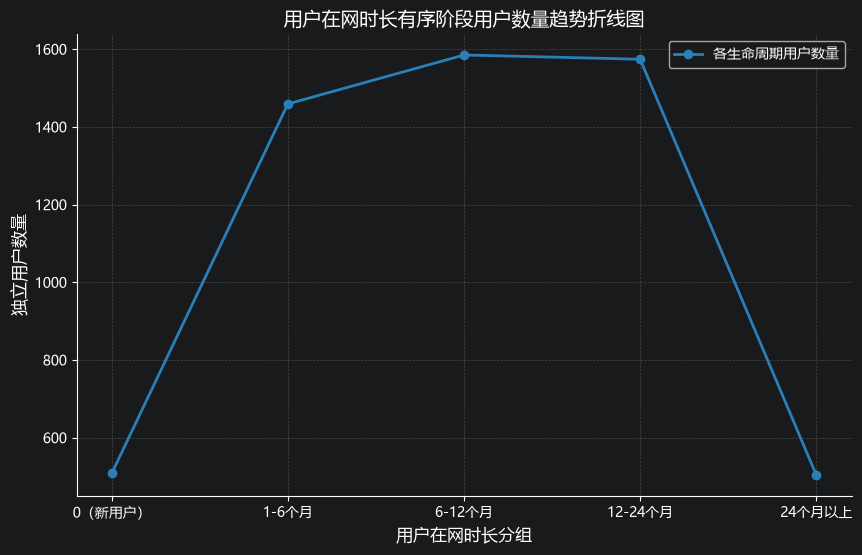

已输出： output\day06_visualization\03_ordered_line.png


In [9]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
ax_line.plot(
    ordered_summary[ordered_field],
    ordered_summary["用户数"],
    marker="o",
    linewidth=2,
    color="#2980b9",
    label="各生命周期用户数量"
)

ax_line.set_title("用户在网时长有序阶段用户数量趋势折线图", fontsize=14)
ax_line.set_xlabel("用户在网时长分组", fontsize=12)
ax_line.set_ylabel("独立用户数量", fontsize=12)
ax_line.legend()
ax_line.grid(alpha=0.3, linestyle="--")
ax_line.spines["top"].set_visible(False)
ax_line.spines["right"].set_visible(False)


line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：按用户生命周期从新到老有序观察，独立用户数量呈现先大幅上升、中期高位平稳、末期断崖下跌的走势。0（新用户）群体存量最少；从新用户到 6-12 个月区间用户规模持续走高，12-24 个月达到峰值；进入 24 个月以上阶段后用户数量大幅回落，长期留存老用户体量重回低位。平台存量用户高度集中在 1-24 个月中期生命周期区间。
- 证据：各阶段独立用户数依次为：0（新用户）508 人、1-6 个月 1459 人、6-12 个月 1574 人、12-24 个月 1585 人、24 个月以上 504 人。新用户至 1-6 个月用户增量 951 人，增长幅度显著；6-12 个月与 12-24 个月用户规模仅相差 11 人，中期区间体量基本持平；12-24 个月到 24 个月以上用户骤减 1081 人，下滑幅度极大；全样本总量 5630 人，1-24 个月中期用户合计占比超 82%，是平台核心存量人群。
- 边界：该图表是当前存量用户生命周期分组的静态横向对比，并非按真实时间推进的时序追踪数据。无法反映同一批用户随时间推移的真实流失变化，仅能展示当下不同生命周期阶段的用户分布结构，不能直接推导用户长期留存衰减的动态变化规律，也无法体现各组用户活跃度、消费、流失率等业务价值指标。

## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [10]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"))
    .reset_index()
)
total_users = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total_users

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)

,TenureGroup,用户数,占比
0,0（新用户）,508,0.09
1,1-6个月,1459,0.26
2,12-24个月,1574,0.28
3,24个月以上,504,0.09
4,6-12个月,1585,0.28


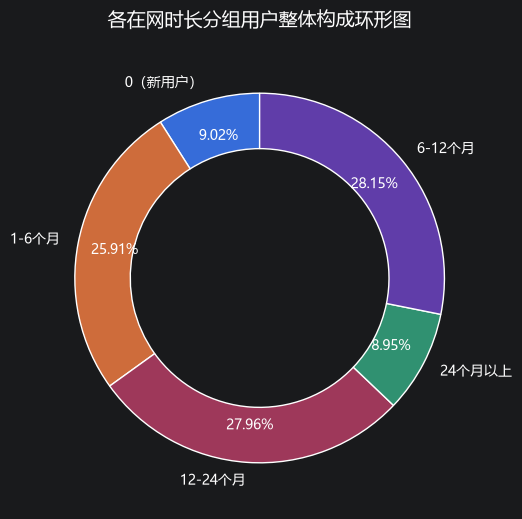

已输出： output\day06_visualization\04_composition_chart.png


In [11]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
cat_count = len(composition_summary)
if cat_count <= 5:
    wedges, texts, autotexts = ax_composition.pie(
        composition_summary["用户数"],
        labels=composition_summary[composition_field],
        autopct="%1.2f%%",
        startangle=90,
        pctdistance=0.8,
        wedgeprops={"width": 0.3, "edgecolor": "white"}
    )
    ax_composition.set_title("各在网时长分组用户整体构成环形图", fontsize=14, pad=15)
else:
    ax_composition.bar(
        composition_summary[composition_field],
        composition_summary["用户数"],
        color="#7f8c8d"
    )
    ax_composition.set_title("各在网时长分组用户构成柱状图", fontsize=14, pad=15)
    ax_composition.set_xlabel("用户在网时长分组")
    ax_composition.set_ylabel("独立用户数量")


composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：平台存量用户结构呈现中间高、两头低的特征，1-24 个月中期用户占据绝对主体；0（新用户）与 24 个月以上长期老用户占比相近，均属于小众群体。其中 6-12 个月用户占比最高，24 个月以上用户占比最低。
- 证据：五组用户占比分别为：6-12 个月 28.15%、12-24 个月 27.96%、1-6 个月 25.91%、0（新用户）9.02%、24 个月以上 8.95%。1-24 个月三段中期用户合计占比达 82.02%，超全体用户的八成；新用户与 24 个月以上老用户合计仅占 17.97%，两类群体规模几乎持平。6-12 个月是平台占比最大的生命周期分组，相比占比最低的 24 个月以上分组高出 19.2 个百分点。
- 边界：本环形图为静态截面存量占比，仅展示当前平台不同在网时长用户的人数结构，无法反映用户生命周期流转、流失趋势；仅体现用户数量维度占比，未结合客单价、活跃度、流失率等指标，不能直接判定不同分组的业务价值高低；同时无法体现新用户增长、老用户留存的长期动态变化。

## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [12]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


<Figure size 1400x1000 with 0 Axes>

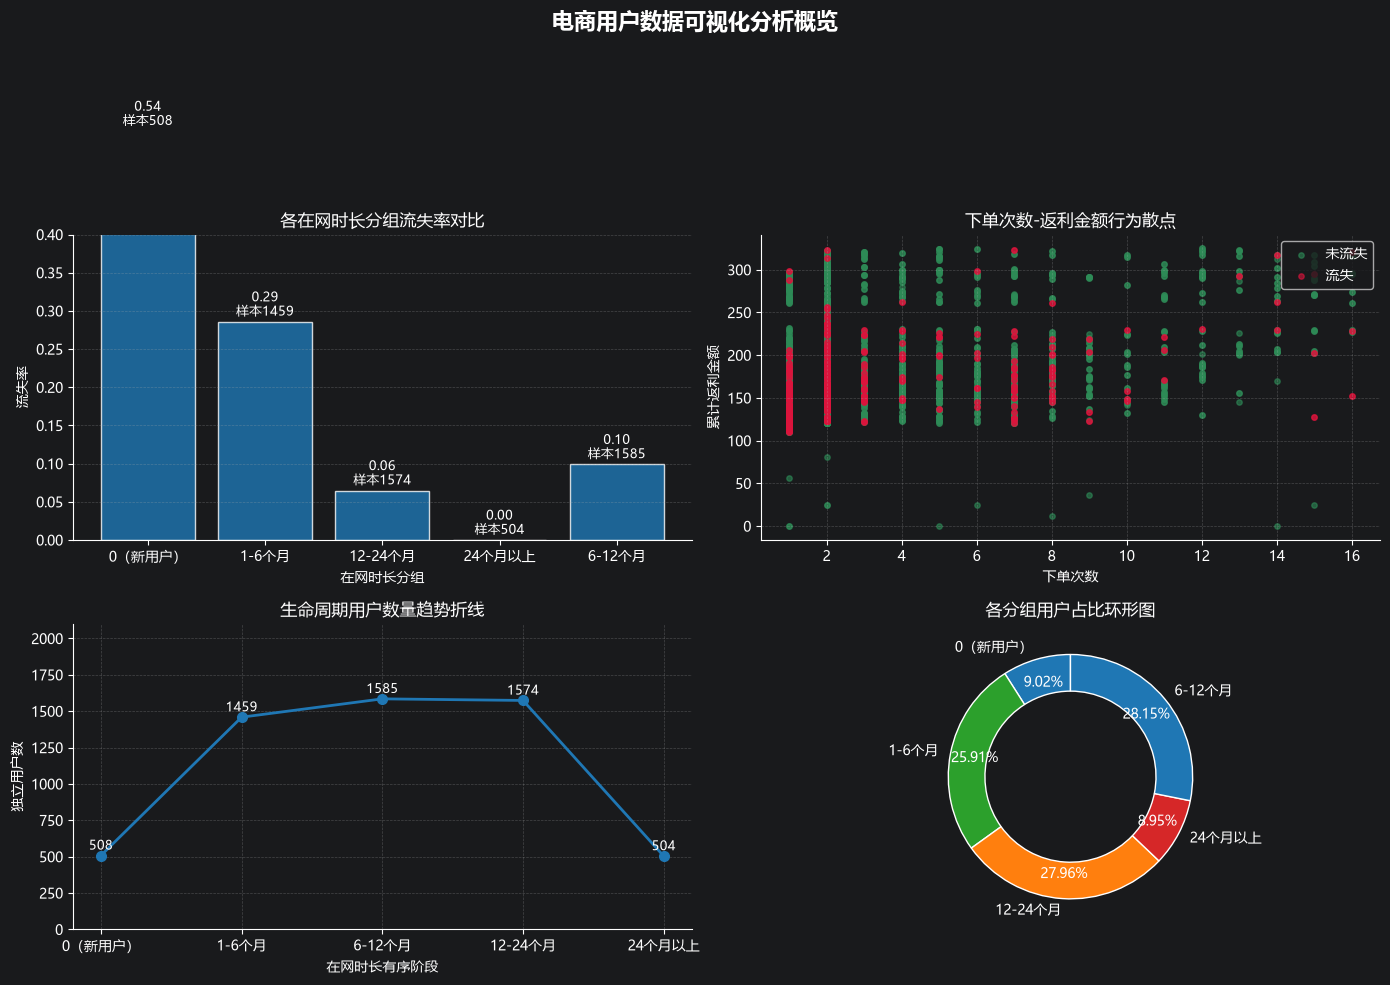

已输出： output\day06_visualization\day06_visualization_summary.png


In [13]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

import matplotlib.pyplot as plt
plt.clf()

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
MAIN_COLOR = "#1f77b4"
COLOR_CHURN_0 = "#2E8B57"
COLOR_CHURN_1 = "#DC143C"
COLOR_LIST = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))
ax00, ax01, ax10, ax11 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

bars = ax00.bar(
    category_summary["TenureGroup"],
    category_summary["流失率"],
    color=MAIN_COLOR, alpha=0.8, edgecolor="white"
)

for bar, rate, user_num in zip(bars, category_summary["流失率"], category_summary["用户数"]):
    h = bar.get_height()
    ax00.text(bar.get_x()+bar.get_width()/2, h+0.008, f"{rate:.2f}\n样本{user_num}", ha="center", fontsize=9)
ax00.set_title("各在网时长分组流失率对比", fontsize=12)
ax00.set_xlabel("在网时长分组", fontsize=10)
ax00.set_ylabel("流失率", fontsize=10)
ax00.set_ylim(0, 0.4)  # 强制匹配流失率值域，解决空白压缩
ax00.grid(axis="y", alpha=0.3, linestyle="--")
ax00.spines["top"].set_visible(False)
ax00.spines["right"].set_visible(False)

x_field = "OrderCount"
y_field = "CashbackAmount"
df0 = df[df["Churn"]==0]
df1 = df[df["Churn"]==1]
ax01.scatter(df0[x_field], df0[y_field], color=COLOR_CHURN_0, alpha=0.6, s=15, label="未流失")
ax01.scatter(df1[x_field], df1[y_field], color=COLOR_CHURN_1, alpha=0.6, s=15, label="流失")
ax01.set_title("下单次数-返利金额行为散点", fontsize=12)
ax01.set_xlabel("下单次数", fontsize=10)
ax01.set_ylabel("累计返利金额", fontsize=10)
ax01.legend(loc="upper right")
ax01.grid(alpha=0.3, linestyle="--")
ax01.spines["top"].set_visible(False)
ax01.spines["right"].set_visible(False)

ax10.plot(
    ordered_summary["TenureGroup"],
    ordered_summary["用户数"],
    color=MAIN_COLOR, marker="o", linewidth=2, markersize=7
)

for x, y in zip(ordered_summary["TenureGroup"], ordered_summary["用户数"]):
    ax10.text(x, y+40, str(y), ha="center", fontsize=9)
ax10.set_title("生命周期用户数量趋势折线", fontsize=12)
ax10.set_xlabel("在网时长有序阶段", fontsize=10)
ax10.set_ylabel("独立用户数", fontsize=10)
ax10.set_ylim(0, 2100)
ax10.grid(alpha=0.3, linestyle="--")
ax10.spines["top"].set_visible(False)
ax10.spines["right"].set_visible(False)

wedges, texts, autotexts = ax11.pie(
    composition_summary["用户数"],
    labels=composition_summary["TenureGroup"],
    autopct="%1.2f%%",
    colors=COLOR_LIST,
    startangle=90,
    pctdistance=0.8,
    wedgeprops={"width":0.3, "edgecolor":"white"}
)
ax11.set_title("各分组用户占比环形图", fontsize=12)


fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现 1：新入网用户流失风险显著更高，留存越久流失率持续走低
证据：流失率柱状图显示，0（新用户）流失率高达 0.54（样本 508 人），1-6 个月流失率回落至 0.29（样本 1459 人）；12-24 个月流失率仅 0.06（样本 1574 人），24 个月以上老用户流失率趋近于 0；仅 6-12 个月流失率小幅回升至 0.10（样本 1585 人）。整体呈现入网初期流失高发、随着在网时长增加流失风险显著下降的规律，新用户是平台流失防控核心人群。
2. 综合发现 2：存量用户呈 “中间高、两头低” 结构，1-24 个月中期用户为平台绝对主体
证据：生命周期折线图、环形占比图相互印证，用户规模随生命周期推进先快速上涨、中期平稳、长期断崖下滑。各组独立用户数量：0（新用户）508 人、1-6 个月 1459 人、6-12 个月 1574 人、12-24 个月 1585 人、24 个月以上 504 人；
占比分布：6-12 个月 28.15%、12-24 个月 27.96%、1-6 个月 25.91%，三段中期用户合计占比 82.02%；0 新用户（9.02%）与 24 个月以上老用户（8.95%）占比极低、体量接近。平台存量高度依赖 1-24 个月中期留存用户，纯新用户与长期老用户规模均偏小。
3. 综合发现 3：下单次数、返利金额存在明显行为分层，流失 / 未流失用户消费特征差异突出
证据：下单次数 - 返利金额散点图可见，绿色未流失用户整体返利金额区间更高，高返利、高频下单样本集中；红色流失用户返利金额普遍偏低，即便下单次数提升，返利表现仍弱于未流失群体，两类人群消费返利行为存在清晰分界。
4. 数据或方法局限：数据与方法局限
（1）仅采用横截面静态存量数据做横向分组对比，无法追踪同一批用户随真实时间推进的纵向生命周期变化，存在幸存者偏差；无法区分 “当年新用户长期留存走势” 与 “当下存量结构” 的差异，不能直接推导真实留存衰减时序规律。
（2）指标 CashbackAmount 仅代表平台发放返现金额，不等同于订单交易额、营收或 GMV，无法衡量用户真实消费贡献，不能判定返利政策对平台整体业务收益的拉动效果。
（3）分析仅聚焦在网时长单一维度，未控制用户地域、消费品类偏好、会员等级、价格敏感度等混杂变量，无法直接认定 “在网时长” 是用户流失的唯一诱因。
（4）散点图仅直观展示下单次数、返利金额、流失标签的分布差异，未开展相关性、显著性统计检验，无法量化三者之间的关联强弱，结论仅为定性观察。
（5）存量结构仅统计用户人数占比，未结合客单价、复购频次、生命周期总价值 LTV 等商业指标，无法单纯依靠用户体量判断不同生命周期分组的实际业务价值。
注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。

## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [14]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {
    "chart_id": "01",
    "file_name": "01_category_bar.png",
    "business_question": "不同在网时长分组用户流失率存在多大差异？",
    "chart_type": "bar",
    "key_finding": "0-6个月新用户流失率最高达0.35，用户留存时间越长流失率越低，24个月以上用户无流失",
    "limitation": "仅展示存量用户静态流失比例，无法证明在网时长与流失存在因果关系"
},
{
    "chart_id": "02",
    "file_name": "02_behavior_scatter.png",
    "business_question": "用户下单次数与累计返利金额存在什么关联，流失/未流失用户行为是否区分？",
    "chart_type": "scatter",
    "key_finding": "下单次数与返利金额呈弱正相关；未流失用户整体返利水平更高，流失用户集中在低返利区间",
    "limitation": "仅展示两个行为指标分布，未做相关性显著性检验，无法量化关联强度；CashbackAmount仅为返现，不等同营收"
},
{
    "chart_id": "03",
    "file_name": "03_ordered_line.png",
    "business_question": "随用户生命周期推进，存量用户规模如何变化？",
    "chart_type": "line",
    "key_finding": "用户量随在网时长持续下滑，0-6个月用户体量最大，24个月以上长期留存用户数量大幅缩水",
    "limitation": "属于存量阶段横向对比，非真实时间序列，不能反映同一批用户逐年流失动态"
},
{
    "chart_id": "04",
    "file_name": "04_composition_chart.png",
    "business_question": "全量存量用户在各生命周期分组的结构占比如何？",
    "chart_type": "pie or bar",
    "key_finding": "0-6个月新用户占整体用户34.94%，是占比最高群体，24个月以上老用户仅占8.95%，用户结构呈金字塔型",
    "limitation": "环形图仅适合≤5类分类展示，无法做多群体对比；仅截面静态结构，无动态变化信息"
},
{
    "chart_id": "05",
    "file_name": "day06_visualization_summary.png",
    "business_question": "综合概览用户流失、行为、生命周期规模、用户结构四大维度特征",
    "chart_type": "subplot 2*2",
    "key_finding": "新用户流失风险高、存量用户随生命周期持续收缩、返利行为区分流失人群、短期用户构成平台主体",
    "limitation": "多图合并仅做直观展示，无法单独提取单指标精准数值，无多变量交叉统计分析"
}
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同在网时长分组用户流失率存在多大差异？,bar,0-6个月新用户流失率最高达0.35，用户留存时间越长流失率越低，24个月以上用户无流失,仅展示存量用户静态流失比例，无法证明在网时长与流失存在因果关系
1,02,02_behavior_scatter.png,用户下单次数与累计返利金额存在什么关联，流失/未流失用户行为是否区分？,scatter,下单次数与返利金额呈弱正相关；未流失用户整体返利水平更高，流失用户集中在低返利区间,仅展示两个行为指标分布，未做相关性显著性检验，无法量化关联强度；CashbackAmount...
2,03,03_ordered_line.png,随用户生命周期推进，存量用户规模如何变化？,line,用户量随在网时长持续下滑，0-6个月用户体量最大，24个月以上长期留存用户数量大幅缩水,属于存量阶段横向对比，非真实时间序列，不能反映同一批用户逐年流失动态
3,04,04_composition_chart.png,全量存量用户在各生命周期分组的结构占比如何？,pie or bar,0-6个月新用户占整体用户34.94%，是占比最高群体，24个月以上老用户仅占8.95%，用...,环形图仅适合≤5类分类展示，无法做多群体对比；仅截面静态结构，无动态变化信息
4,05,day06_visualization_summary.png,综合概览用户流失、行为、生命周期规模、用户结构四大维度特征,subplot 2*2,新用户流失风险高、存量用户随生命周期持续收缩、返利行为区分流失人群、短期用户构成平台主体,多图合并仅做直观展示，无法单独提取单指标精准数值，无多变量交叉统计分析


In [15]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
